# Load Data

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [11]:
sensor_names = ['s_{}' .format(i) for i in range(1, 22)]
col_names = ['unit_num', 'time_cycle', 'setting1', 'setting2', 'setting3'] + sensor_names

In [46]:
train = pd.read_csv('./data/train_FD001.txt', sep='\s+', header=None, names=col_names)
test = pd.read_csv('./data/test_FD001.txt', sep='\s+', header=None, names=col_names)
rul = pd.read_csv('./data/RUL_FD001.txt', sep='\s+', header=None, names=['RUL'])


# Prep Data

In [47]:
# RUL = max cycle - current cycle
# Calculate max cycle for each unit
max_cycle = train.groupby('unit_num')['time_cycle'].max().reset_index()
max_cycle.columns = ['unit_num', 'max']

# Merge and calculate RUL
train = train.merge(max_cycle, on='unit_num', how='left')
train['RUL'] = train['max'] - train['time_cycle']
train.drop('max', axis=1, inplace=True)



In [82]:
# Drop all columns with no change (no predictive value)
stats = train.describe().T
constants = stats[stats['std'] == 0].index.tolist()

train.drop(columns=constants, inplace=True)
test.drop(columns=constants, inplace=True)

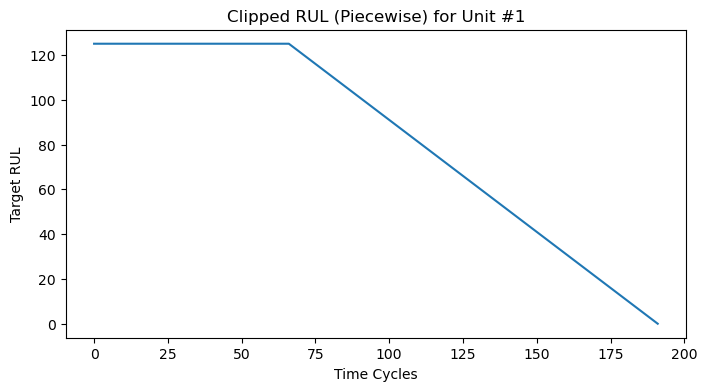

In [49]:
# Define the threshold (125 is a standard choice for FD001)
RUL_THRESHOLD = 125

# Clip the RUL values
train['RUL'] = train['RUL'].clip(upper=RUL_THRESHOLD)

# Let's visualize the change for Unit #1
plt.figure(figsize=(8, 4))
plt.plot(train[train['unit_num'] == 1]['RUL'])
plt.title('Clipped RUL (Piecewise) for Unit #1')
plt.xlabel('Time Cycles')
plt.ylabel('Target RUL')
plt.show()


# EDA

In [55]:
# Scale to normalize data to a [0, 1] range
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
# Don't scale 'unit_nr', 'time_cycles', or 'RUL'
features = [c for c in train.columns if c not in ['unit_nr', 'time_cycles', 'RUL']]

train[features] = scaler.fit_transform(train[features])
test[features] = scaler.transform(test[features])

In [53]:
# Finding the sensors with high standard deviation values
sensor_cols = [c for c in train.columns if 's_' in c]
sensor_stats = train[sensor_cols].std().sort_values(ascending=False)
high_std_sensors = sensor_stats[sensor_stats > 0].index.tolist()
constant_sensors = sensor_stats[sensor_stats == 0].index.tolist()

print(f"Useful Sensors: {high_std_sensors}")
print(f"Useless (Constant) Sensors: {constant_sensors}")

Useful Sensors: ['s_11', 's_12', 's_4', 's_2', 's_21', 's_15', 's_7', 's_20', 's_6', 's_3', 's_17', 's_8', 's_13', 's_9', 's_14']
Useless (Constant) Sensors: ['s_1', 's_16', 's_5', 's_10']


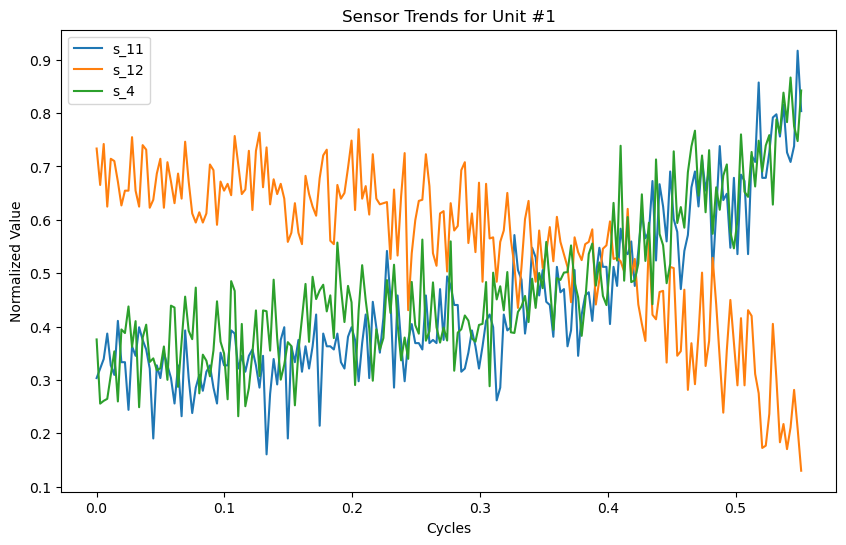

In [54]:
# Plotting a few high standard deviation sensors for unit 1
unit_1 = train[train['unit_num'] == 1]

plt.figure(figsize=(10, 6))
for sensor in ['s_11', 's_12', 's_4']:
    plt.plot(unit_1['time_cycle'], unit_1[sensor], label=sensor)

plt.title('Sensor Trends for Unit #1')
plt.xlabel('Cycles')
plt.ylabel('Normalized Value')
plt.legend()
plt.show()

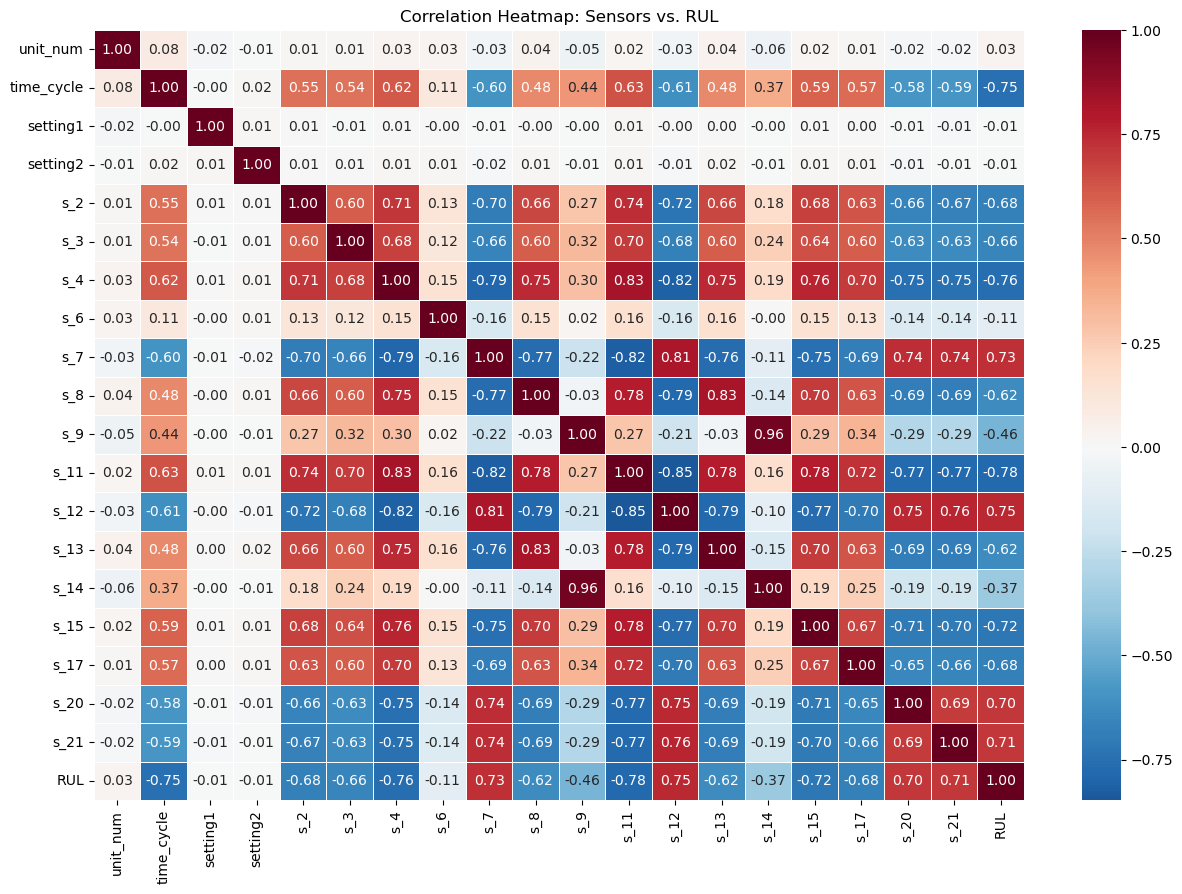

In [57]:
# identify correlations between sensors and RUL
non_constant_cols = [c for c in train.columns if train[c].std() > 0]
df_corr = train[non_constant_cols].corr()

plt.figure(figsize=(15, 10))
sns.heatmap(df_corr, annot=True, fmt=".2f", cmap='RdBu_r', center=0, linewidths=0.5)
plt.title('Correlation Heatmap: Sensors vs. RUL')
plt.show()

In [80]:
# Get top 10 sensors with the highest correlation
correlations = train.corr()['RUL'].abs().sort_values(ascending=False)
top_10_sensors = correlations.drop(['RUL', 'unit_num', 'time_cycle'], errors='ignore').head(10).index.tolist()
print(top_10_sensors)

['s_11', 's_4', 's_12', 's_7', 's_15', 's_21', 's_20', 's_17', 's_2', 's_3']


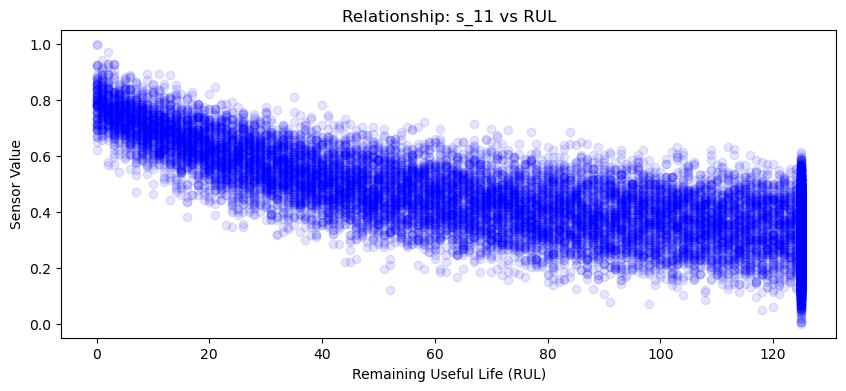

In [111]:
# Validating feature selection
best_sensor = top_10_sensors[0]

plt.figure(figsize=(10, 4))
plt.scatter(train['RUL'], train[best_sensor], alpha=0.1, color='blue')
plt.title(f'Relationship: {best_sensor} vs RUL')
plt.xlabel('Remaining Useful Life (RUL)')
plt.ylabel('Sensor Value')
plt.show()

# Model Fitting

### Multiple Linear Regression (First Attempt)

In [87]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [88]:
# Use top 10 sensors to train multiple linear regression model
X_train = train[top_10_sensors]
y_train = train['RUL']

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_train = lr_model.predict(X_train)

rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
mae = mean_absolute_error(y_train, y_pred_train)
r2 = r2_score(y_train, y_pred_train)

print(f'RMSE: {rmse: .2f}')
print(f'MAE: {mae: .2f}')
print(f'R2 Score: {r2: .2f}')

RMSE:  23.19
MAE:  18.85
R2 Score:  0.69


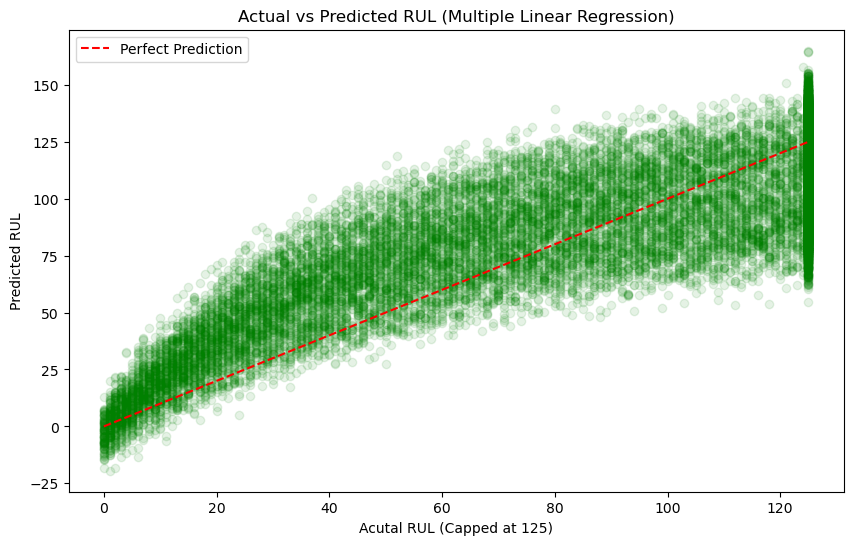

In [89]:
plt.figure(figsize=(10,6))
plt.scatter(y_train, y_pred_train, alpha=0.1, color='green')
plt.plot([0, 125], [0, 125], color='red', linestyle='--', label='Perfect Prediction')
plt.title('Actual vs Predicted RUL (Multiple Linear Regression)')
plt.xlabel('Acutal RUL (Capped at 125)')
plt.ylabel('Predicted RUL')
plt.legend()
plt.show()

### Polynomial Regression

In [91]:
# Use top 10 sensors to train polynomial regression model
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X_train)

poly_model = LinearRegression()
poly_model.fit(X_poly, y_train)
y_pred_poly = poly_model.predict(X_poly)

poly_rmse = np.sqrt(mean_squared_error(y_train, y_pred_poly))
poly_mae = mean_absolute_error(y_train, y_pred_poly)
poly_r2 = r2_score(y_train, y_pred_poly)

print(f'RMSE: {poly_rmse: .2f}')
print(f'MAE: {poly_mae: .2f}')
print(f'R2 Score: {poly_r2: .2f}')

RMSE:  22.52
MAE:  18.05
R2 Score:  0.71


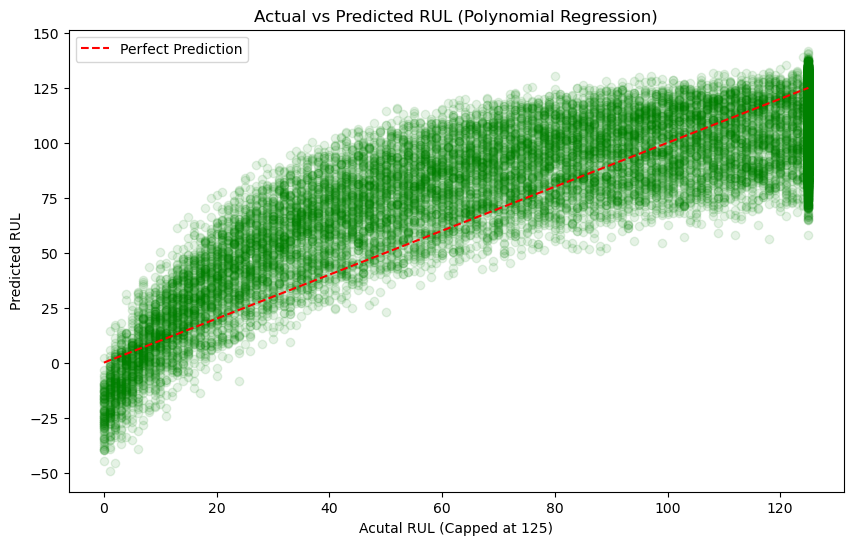

In [92]:
plt.figure(figsize=(10,6))
plt.scatter(y_train, y_pred_poly, alpha=0.1, color='green')
plt.plot([0, 125], [0, 125], color='red', linestyle='--', label='Perfect Prediction')
plt.title('Actual vs Predicted RUL (Polynomial Regression)')
plt.xlabel('Acutal RUL (Capped at 125)')
plt.ylabel('Predicted RUL')
plt.legend()
plt.show()

### Multiple Linear Regression (2nd Attempt)

In [94]:
# Use top 5 sensors to train multiple linear regression model
top_5_sensors = top_10_sensors[:5]
X_train = train[top_5_sensors]
y_train = train['RUL']

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_train = lr_model.predict(X_train)

rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
mae = mean_absolute_error(y_train, y_pred_train)
r2 = r2_score(y_train, y_pred_train)

print(f'RMSE: {rmse: .2f}')
print(f'MAE: {mae: .2f}')
print(f'R2 Score: {r2: .2f}')

RMSE:  24.00
MAE:  19.51
R2 Score:  0.67


In [96]:
# Feature engineering: apply a rolling mean to smooth sensor noise
# Train a linear regression model on top 5 smoothed sensor data 
WINDOW_SIZE = 5

train_smoothed = train.copy()
train_smoothed[top_5_sensors] = train.groupby('unit_num')[top_5_sensors].transform(
    lambda x: x.rolling(window=WINDOW_SIZE, min_periods=1).mean()
)

X_train_smooth = train_smoothed[top_5_sensors]
y_train = train_smoothed['RUL']

smooth_model = LinearRegression()
smooth_model.fit(X_train_smooth, y_train)
y_pred_smooth = smooth_model.predict(X_train_smooth)

smooth_rmse = np.sqrt(mean_squared_error(y_train, y_pred_smooth))
smooth_mae = mean_absolute_error(y_train, y_pred_smooth)
smooth_r2 = r2_score(y_train, y_pred_smooth)

print(f'RMSE: {smooth_rmse:.2f}')
print(f'MAE: {smooth_mae:.2f}')
print(f'R2 Score: {smooth_r2:.2f}')

RMSE: 23.30
MAE: 18.93
R2 Score: 0.69


In [97]:
# Predict RUL on the test set using smoothed data from the final engine cycles
test_smoothed = test.copy()
test_smoothed[top_5_sensors] = test.groupby('unit_num')[top_5_sensors].transform(
    lambda x: x.rolling(window=WINDOW_SIZE, min_periods=1).mean()
)

test_last_cycle = test_smoothed.groupby('unit_num').last().reset_index()
X_test = test_last_cycle[top_5_sensors]
y_test_pred = smooth_model.predict(X_test)
y_test_actual = rul['RUL']

test_rmse = np.sqrt(mean_squared_error(y_test_actual, y_test_pred))
test_mae = mean_absolute_error(y_test_actual, y_test_pred)
test_r2 = r2_score(y_test_actual, y_test_pred)

print(f'RMSE: {test_rmse:.2f}')
print(f'MAE: {test_mae:.2f}')
print(f'R2 Score: {test_r2:.2f}')

RMSE: 23.95
MAE: 19.74
R2 Score: 0.67


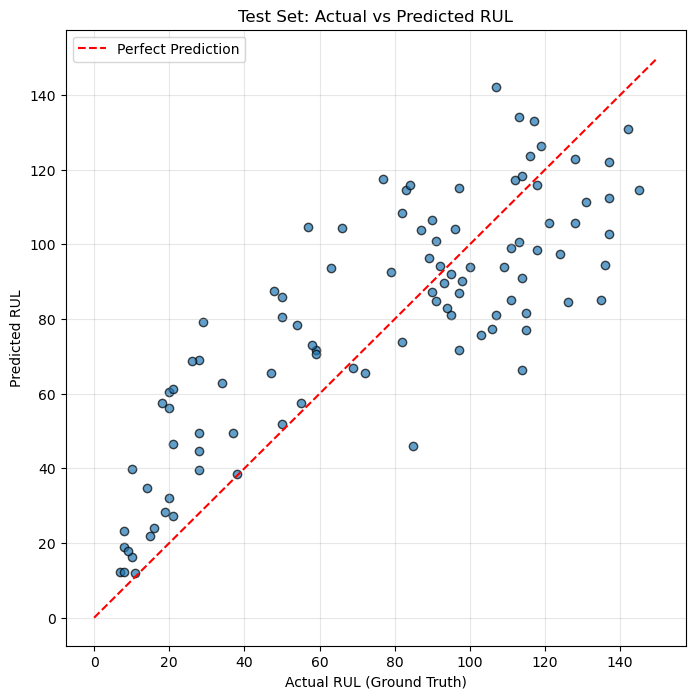

In [98]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test_actual, y_test_pred, alpha=0.7, edgecolors='k')
plt.plot([0, 150], [0, 150], color='red', linestyle='--', label='Perfect Prediction')
plt.title('Test Set: Actual vs Predicted RUL')
plt.xlabel('Actual RUL (Ground Truth)')
plt.ylabel('Predicted RUL')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [102]:
# Smooth data and train model for top 10 sensors
train_10_smoothed = train.copy()
train_10_smoothed[top_10_sensors] = train.groupby('unit_num')[top_10_sensors].transform(
    lambda x: x.rolling(window=WINDOW_SIZE, min_periods=1).mean()
)

X_train_10 = train_10_smoothed[top_10_sensors]
y_train = train['RUL']

model_10 = LinearRegression()
model_10.fit(X_train_10, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [104]:
# Validate the 10 sensor smoothed model on the test set
test_10_smoothed = test.copy()
test_10_smoothed[top_10_sensors] = test.groupby('unit_num')[top_10_sensors].transform(
    lambda x: x.rolling(window=WINDOW_SIZE, min_periods=1).mean()
)

X_test_10 = test_10_smoothed.groupby('unit_num').last().reset_index()[top_10_sensors]
y_test_pred_10 = model_10.predict(X_test_10)

test_rmse_10 = np.sqrt(mean_squared_error(y_test_actual, y_test_pred_10))
test_mae_10 = mean_absolute_error(y_test_actual, y_test_pred_10)
test_r2_10 = r2_score(y_test_actual, y_test_pred_10)

print(f'RMSE: {test_rmse_10:.2f}')
print(f'MAE: {test_mae_10:.2f}')
print(f'R2 Score: {test_r2_10:.2f}')

RMSE: 23.02
MAE: 18.71
R2 Score: 0.69


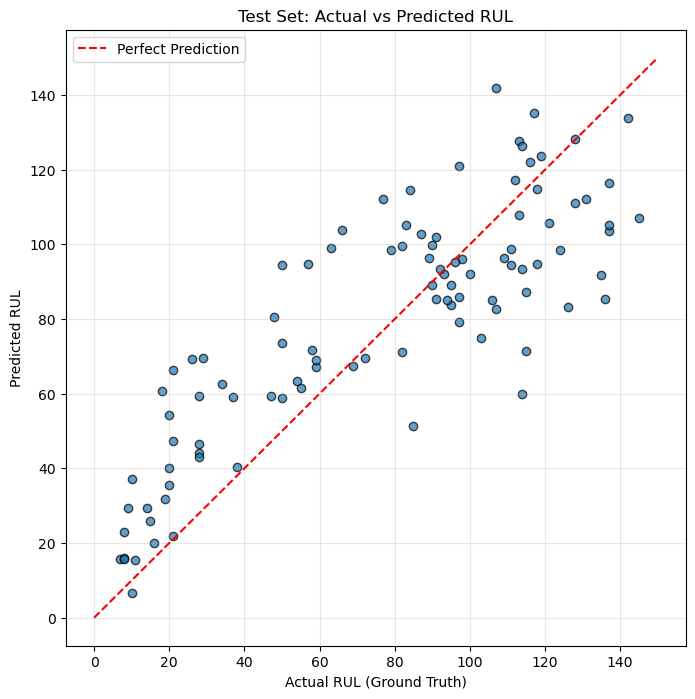

In [105]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test_actual, y_test_pred_10, alpha=0.7, edgecolors='k')
plt.plot([0, 150], [0, 150], color='red', linestyle='--', label='Perfect Prediction')
plt.title('Test Set: Actual vs Predicted RUL')
plt.xlabel('Actual RUL (Ground Truth)')
plt.ylabel('Predicted RUL')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### Random Forest Regressor

In [108]:
# This model captures non-linear patterns and sensor interactions that linear regression misses
# Achieved best performance with RMSE of 21.08
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train_10, y_train)

y_test_pred_rf = rf_model.predict(X_test_10)

rf_rmse = np.sqrt(mean_squared_error(y_test_actual, y_test_pred_rf))
rf_mae = mean_absolute_error(y_test_actual, y_test_pred_rf)
rf_r2 = r2_score(y_test_actual, y_test_pred_rf)

print(f'RMSE: {rf_rmse:.2f}')
print(f'MAE: {rf_mae:.2f}')
print(f'R2 Score: {rf_r2:.2f}')

RMSE: 21.08
MAE: 15.83
R2 Score: 0.74


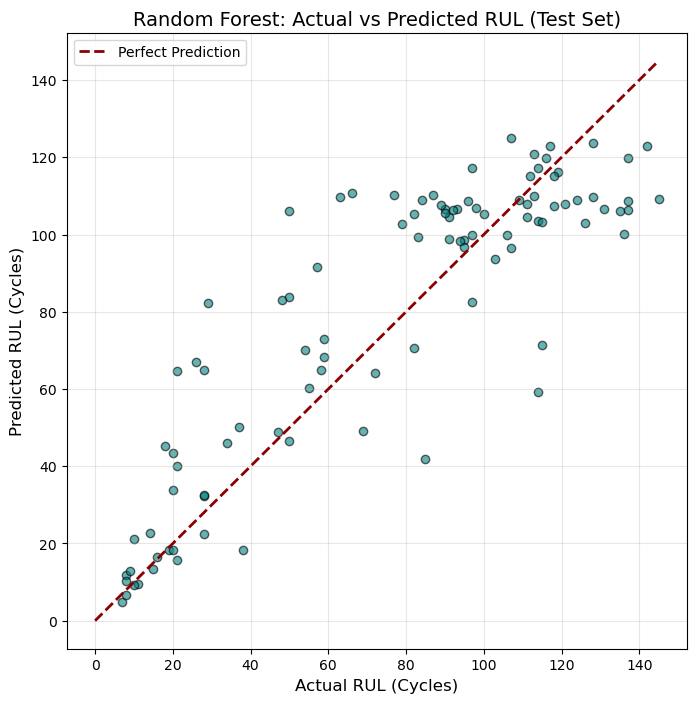

In [110]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test_actual, y_test_pred_rf, alpha=0.6, color='teal', edgecolors='k')

plt.plot([0, y_test_actual.max()], [0, y_test_actual.max()], 
         color='darkred', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.title('Random Forest: Actual vs Predicted RUL (Test Set)', fontsize=14)
plt.xlabel('Actual RUL (Cycles)', fontsize=12)
plt.ylabel('Predicted RUL (Cycles)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

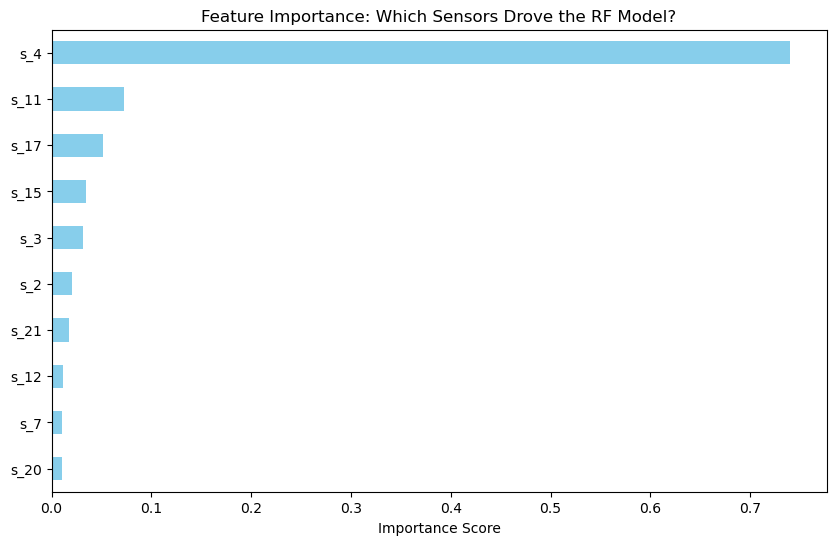

In [109]:
# Visualizing the contribution of each sensor to the final model
importances = pd.Series(rf_model.feature_importances_, index=top_10_sensors)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='skyblue')
plt.title('Feature Importance: Which Sensors Drove the RF Model?')
plt.xlabel('Importance Score')
plt.show()